In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df=pd.read_csv("Advertising.csv")

In [19]:
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [20]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [21]:
df.drop("Unnamed: 0",inplace=True,axis=1)

In [22]:

df.shape

(200, 4)

In [23]:
X=df[["TV","Radio","Newspaper"]]

y=df["Sales"]

In [24]:
from sklearn.linear_model import Lasso

In [25]:
model=Lasso(alpha=2,max_iter=5000)

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

In [27]:
model.fit(X_train,y_train)

Lasso(alpha=2, max_iter=5000)

In [28]:
y_pred=model.predict(X_test)

In [29]:
from sklearn.metrics import r2_score,mean_squared_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.9009870648859587
3.1252040599347084


In [30]:
print(pd.Series(model.coef_,index=X.columns))

TV           0.044532
Radio        0.181501
Newspaper    0.000084
dtype: float64


Text(0, 0.5, 'Coeff Values')

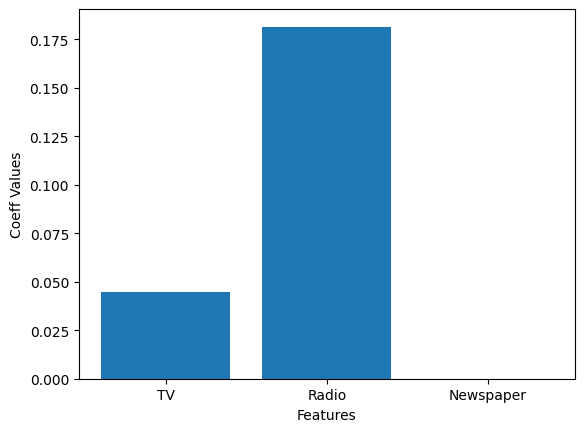

In [31]:
coef=model.coef_
plt.bar(X.columns,coef)
plt.xlabel("Features")
plt.ylabel("Coeff Values")

Alpha=[1.00000000e-03 1.20679264e-03 1.45634848e-03 1.75751062e-03
 2.12095089e-03 2.55954792e-03 3.08884360e-03 3.72759372e-03
 4.49843267e-03 5.42867544e-03 6.55128557e-03 7.90604321e-03
 9.54095476e-03 1.15139540e-02 1.38949549e-02 1.67683294e-02
 2.02358965e-02 2.44205309e-02 2.94705170e-02 3.55648031e-02
 4.29193426e-02 5.17947468e-02 6.25055193e-02 7.54312006e-02
 9.10298178e-02 1.09854114e-01 1.32571137e-01 1.59985872e-01
 1.93069773e-01 2.32995181e-01 2.81176870e-01 3.39322177e-01
 4.09491506e-01 4.94171336e-01 5.96362332e-01 7.19685673e-01
 8.68511374e-01 1.04811313e+00 1.26485522e+00 1.52641797e+00
 1.84206997e+00 2.22299648e+00 2.68269580e+00 3.23745754e+00
 3.90693994e+00 4.71486636e+00 5.68986603e+00 6.86648845e+00
 8.28642773e+00 1.00000000e+01]| Coefficients =[0.04472941 0.18919132 0.00275974]
Alpha=[1.00000000e-03 1.20679264e-03 1.45634848e-03 1.75751062e-03
 2.12095089e-03 2.55954792e-03 3.08884360e-03 3.72759372e-03
 4.49843267e-03 5.42867544e-03 6.55128557e-03 7.9060

Text(0.5, 1.0, 'Lasso Regression')

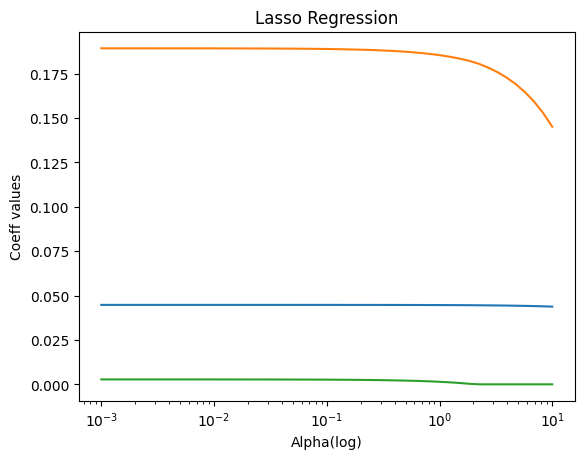

In [32]:
alphas=np.logspace(-3,1,50)
coeff_path=[]
for alph in alphas:
    lasso=Lasso(alpha=alph,max_iter=5000)
    lasso.fit(X_train,y_train)
    coeff_path.append(lasso.coef_)
    print(f"Alpha={alphas}| Coefficients ={lasso.coef_}")
coeff_path=np.array(coeff_path)
plt.plot(alphas,coeff_path)
plt.xscale("log")
plt.xlabel("Alpha(log)")
plt.ylabel("Coeff values")
plt.title("Lasso Regression")